# Taller de Python para Álgebra Superior
Pablo Carpio Martínez
## Sesión 8 & 9 
## Polinomios

### Declaración de un polinomio

Un polinomio en la variable $x$ es una expresión de la forma

$$
p(x)=a_nx^n+a_{n-1}x^{n-1}+\cdots+a_1x+a_0,
$$

Para trabajar con polinomios en Python podemos usar np.poly1d() o SymPy.

Ejemplo:

Tomemos los polinomios

$$
p(x)=x^3+2x+1
$$

y

$$
q(x)=x^2+x-3.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [ ]:
# Usando poly1d

p_np = np.poly1d([1, 0, 2, 1])
q_np = np.poly1d([1, 1, -3])

print(type(p_np))
print(p_np)
print(q_np)

<class 'numpy.poly1d'>
   3
1 x + 2 x + 1
   2
1 x + 1 x - 3


In [ ]:
# Usando SymPy

x = sp.Symbol('x')

p_sp = x**3 + 2*x + 1
q_sp = x**2 + x - 3

display(p_sp)
display(q_sp)

x**3 + 2*x + 1

x**2 + x - 3

### Evaluación de un polinomio en $x = a$

In [ ]:
# poly1d

p_np(2)

np.int64(13)

In [ ]:
# SymPy

p_sp.subs(x, 2)

13

### Ejercicio
Represente el polinomio $q(x)$ en Python y evalúelo en $x=-1$ usando np.poly1d() y SymPy.


$$
q(x)=x^4-3x^3+2x^2+x-5.
$$



In [ ]:
r_np = np.poly1d([1, -3, 2, 1, -5])
print(r_np)
print(r_np(-1))

x = sp.Symbol('x')
r_sp = x**4 - 3*x**3 + 2*x**2 + x - 5
display(r_sp)

r_sp.subs(x, -1)

   4     3     2
1 x - 3 x + 2 x + 1 x - 5
0


x**4 - 3*x**3 + 2*x**2 + x - 5

0

### Operaciones con polinomios

### Suma


In [ ]:
# poly1d

p_np + q_np

poly1d([ 1,  1,  3, -2])

In [ ]:
# SymPy

sp.expand(p_sp + q_sp)

x**3 + x**2 + 3*x - 2

### Multiplicación

In [ ]:
# poly1d

p_np*q_np

poly1d([ 1,  1, -1,  3, -5, -3])

In [ ]:
# SymPy

sp.expand(p_sp*q_sp)


x**5 + x**4 - x**3 + 3*x**2 - 5*x - 3

### División


In [ ]:
# poly1d

cociente_np, residuo_np = np.polydiv(p_np, q_np)

print("Cociente:")
print(cociente_np)

print("Residuo:")
print(residuo_np)

Cociente:
 
1 x - 1
Residuo:
 
6 x - 2


In [ ]:
# SymPy

cociente_sp, residuo_sp = sp.div(p_sp, q_sp)

print("Cociente:")
display(cociente_sp)

print("Residuo:")
display(residuo_sp)

Cociente:


x - 1

Residuo:


6*x - 2

### Ejercicio

Considere los polinomios

$$
p(x)=x^3+2x+1
$$

y

$$
q(x)=x^2+x-3.
$$

Realice las operaciones:

1. $p(x)+q(x)$
2. $p(x)-q(x)$
3. $p(x)q(x)$


In [ ]:
p_x = x**3+2*x+1
q_x = x**2+x-3

display(p_x+q_x)
display(p_x-q_x)
display(sp.expand(p_x*q_x))
(cociente_x, residuo_x) = sp.div(p_x , q_x)
display("Cociente:",cociente_x)
display("Residuo:",residuo_x)

x**3 + x**2 + 3*x - 2

x**3 - x**2 + x + 4

x**5 + x**4 - x**3 + 3*x**2 - 5*x - 3

'Cociente:'

x - 1

'Residuo:'

6*x - 2

In [ ]:
# usando poly1d

t_np = np.poly1d([1, 0, 2, 1])
u_np = np.poly1d([1, 1, -3])

# suma
print(t_np + u_np)

# resta
print(t_np + u_np)

#multiplicación
print(t_np*u_np)

   3     2
1 x + 1 x + 3 x - 2
   3     2
1 x + 1 x + 3 x - 2
   5     4     3     2
1 x + 1 x - 1 x + 3 x - 5 x - 3


### División sintética



In [ ]:
# División de un polinomio entre el término (x - a)

def div_sint(coeficientes, a):

    b = [coeficientes[0]]

    for i in range(1, len(coeficientes)):

        b.append(coeficientes[i] + a*b[i - 1])

    cociente = b[:-1]
    residuo = b[-1]

    return cociente, residuo

pcoeficientes = [-1, -6, 11, -6]
b = 2

r_cociente, r_residuo = div_sint(pcoeficientes, b)

print("Coeficientes del cociente:", r_cociente)
print("Residuo:", r_residuo)
print(np.poly1d(r_cociente))

Coeficientes del cociente: [-1, -8, -5]
Residuo: -16
    2
-1 x - 8 x - 5


### Ejercicio
Considere el polinomio

$$
f(x)=3x^5-4x^4-5x^3-8x+25.
$$

Halle el cociente y el residuo al dividir $f(x)$ entre $x-2$. Finalmente, exprese el polinomio en la forma

$$
f(x)=(x-a)Q(x)+R(x).
$$

In [ ]:
def div_sint(coeficientes, a):

    b = [coeficientes[0]]

    for i in range(1, len(coeficientes)):

        b.append(coeficientes[i] + a*b[i-1])

    cociente = b[:-1]
    residuo = b[-1]

    return cociente, residuo

pcoeficientes = [3, -4, -5, 0, -8, 25]
b = 2

r_cociente, r_residuo = div_sint(pcoeficientes, b)

x = sp.Symbol("x")

Q_sp = sp.Poly(r_cociente, x).as_expr()
Q_sp

sp.Eq(sp.Function("f")(x), (x - b)*Q_sp + r_residuo)

# print("Coeficientes del cociente:", r_cociente)
# print("Residuo:", r_residuo)
# print(np.poly1d(r_cociente))


Eq(f(x), (x - 2)*(3*x**4 + 2*x**3 - x**2 - 2*x - 12) + 1)

###  Probar las posibles raíces racionales mediante división sintética

Para el polinomio

$$
p(x)=x^3-4x^2+x+6,
$$

los divisores del término independiente son

$$
p=1,\ 2,\ 3,\ 6,
$$

mientras que los divisores del coeficiente principal son

$$
q=1.
$$

Por lo tanto, las posibles raíces racionales son

$$
\frac{p}{q} = \pm1,\ \pm2,\ \pm3,\ \pm6.
$$

Utilice la función `div_sint()` para determinar cuáles de los valores anteriores corresponden a raíces racionales de $p(x)$.


In [ ]:
pcoeficientes = [1, -4, 1, 6]

posibles_raíces = [1, -1, 2, -2, 3, -3, 6, -6]


for r in posibles_raíces:

    r_cociente, r_residuo = div_sint(pcoeficientes, r)

    # print(f"r = {r}")
    # print("Residuo:", r_residuo)

    if r_residuo == 0:
    #if np.isclose(r_residuo, 0):

        print(f"{r:<2} es una raíz de p(x)")

-1 es una raíz de p(x)
2  es una raíz de p(x)
3  es una raíz de p(x)


Lista de posibles raíces

In [ ]:

q_div = sp.divisors(pcoeficientes[0])
p_div = sp.divisors(pcoeficientes[-1])

posibles_raices = []

for p in p_div:
    for q in q_div:

        r = p/q

        posibles_raices.append(r)
        posibles_raices.append(-r)

print(set(posibles_raices))

{1.0, 2.0, 3.0, 6.0, -2.0, -6.0, -3.0, -1.0}


### Ejercicio
Considere el polinomio
$$
p(x)=4x^4-4x^3-25x^2+x+6.
$$
Determine las raíces racionales de $p(x)$, si es que las hay

### Raíces de un polinomio

Tomemos como ejemplo $$
p(x)=x^4-5x^2+4.
$$

Con poly1d

In [ ]:
p_np = np.poly1d([1, 0, -5, 0, 4])

raices = np.roots(p_np)

raices

array([-2.,  2., -1.,  1.])

In [ ]:
p_np.r

array([-2.,  2., -1.,  1.])

Con SymPy:

In [ ]:
x = sp.symbols("x")

p = x**4 - 5*x**2 + 4

p_sp = sp.Poly(p)

p_sp

Poly(x**4 - 5*x**2 + 4, x, domain='ZZ')

In [ ]:
p_sp.all_roots()

[-2, -1, 1, 2]

### Ejercicio

Considere el polinomio

$$
p(x)=x^4-10x^2+9.
$$

Obtenga todas sus raíces utilizando SymPy.


In [ ]:
x = sp.symbols("x")

p = x**4 - 10*x**2 + 9

p_sp = sp.Poly(p)

p_sp.all_roots()

[-3, -1, 1, 3]

### Regla de los signos de Descartes

In [ ]:
# obtener el grado y los coeficientes de un polinomio usando SymPy

p = x**5 - 1

grado = sp.degree(p)

coeficientes = sp.Poly(p, x).all_coeffs()

coeficientes


[1, 0, 0, 0, 0, -1]

In [ ]:
# Como hacer la composición p(-x)

p_comp = sp.Poly(p.subs(x, -x), x)
p_comp

Poly(-x**5 - 1, x, domain='ZZ')

In [ ]:
from mpmath.functions.rszeta import coef
p = x**4 - 3*x**3 - 7*x**2 + 27*x - 18

grado = sp.degree(p)

def cambios_de_signo(pcoeficientes):

    coeficientes = [c for c in pcoeficientes if c != 0]

    cambios = 0

    for i in range(len(coeficientes)-1):

        if coeficientes[i]*coeficientes[i + 1] < 0:

            cambios += 1

    return cambios

positivas =  cambios_de_signo(sp.Poly(p, x).all_coeffs())
negativas =  cambios_de_signo(sp.Poly(p.subs(x, -x), x).all_coeffs())

print("Posibles raíces positivas:")
for n_pos in range(positivas, -1, -2):

    print(f"{n_pos} positivas")

print("\nPosibles raíces negativas:")
for n_neg in range(negativas, -1, -2):

    print(f"{n_neg} negativas")

print("\nCombinaciones posibles:")

for n_pos in range(positivas, -1, -2):
    for n_neg in range(negativas, -1, -2):

        n_comp = grado - n_pos - n_neg

        print(f"{n_pos} positivas, {n_neg} negativas y {n_comp} complejas")



Posibles raíces positivas:
3 positivas
1 positivas

Posibles raíces negativas:
1 negativas

Combinaciones posibles:
3 positivas, 1 negativas y 0 complejas
1 positivas, 1 negativas y 2 complejas


Cómo obtener los coeficientes y el grado con SymPy.

### Ejercicio

Considere el polinomio

$$
p(x)=x^5-4x^4+3x^3+2x^2-8.
$$

Aplique la regla de los signos de Descartes para determinar las posibles raíces positivas, negativas y complejas.


In [ ]:
x = sp.symbols('x')

p = x**5 - 4*x**4 + 3*x**3 + 2*x**2 - 8

grado = sp.degree(p)

positivas = cambios_de_signo(sp.Poly(p, x).all_coeffs())
negativas = cambios_de_signo(sp.Poly(p.subs(x, -x), x).all_coeffs())

print("Posibles raíces positivas:")
for n_pos in range(positivas, -1, -2):
    print(f"{n_pos} positivas")

print("\nPosibles raíces negativas:")
for n_neg in range(negativas, -1, -2):
    print(f"{n_neg} negativas")

print("\nCombinaciones posibles:")
for n_pos in range(positivas, -1, -2):
    for n_neg in range(negativas, -1, -2):
        n_comp = grado - n_pos - n_neg
        print(f"{n_pos} positivas, {n_neg} negativas y {n_comp} complejas")

Posibles raíces positivas:
3 positivas
1 positivas

Posibles raíces negativas:
2 negativas
0 negativas

Combinaciones posibles:
3 positivas, 2 negativas y 0 complejas
3 positivas, 0 negativas y 2 complejas
1 positivas, 2 negativas y 2 complejas
1 positivas, 0 negativas y 4 complejas


### Polinomios y sus gráficas

Máximos y mínimos de un polinomio

Ejemplo:

Para el polinomio $p(x)=x^4-5x^2+4$, podemos calcular sus puntos críticos y aplicar el criterio de la segunda derivada

In [2]:
p = np.poly1d([1, 0, -5, 0, 4])

# Calculo de la derivada

dp = p.deriv()

print(dp)

   3
4 x - 10 x


In [3]:
# Ubicamos los puntos críticos (raíces de la derivada)
criticos = dp.r

print(criticos)

[-1.58113883  1.58113883  0.        ]


In [4]:
# Clasificamos de acuerdo al criterio de la segunda derivada
d2p = dp.deriv()

for x in criticos:
    if d2p(x) > 0:
        tipo = "mínimo"
    elif d2p(x) < 0:
        tipo = "máximo"
    else:
        tipo = "indeterminado"

    print(f"x={x:8.4f}, p(x)={p(x):8.4f}, {tipo}")

x= -1.5811, p(x)= -2.2500, mínimo
x=  1.5811, p(x)= -2.2500, mínimo
x=  0.0000, p(x)=  4.0000, máximo


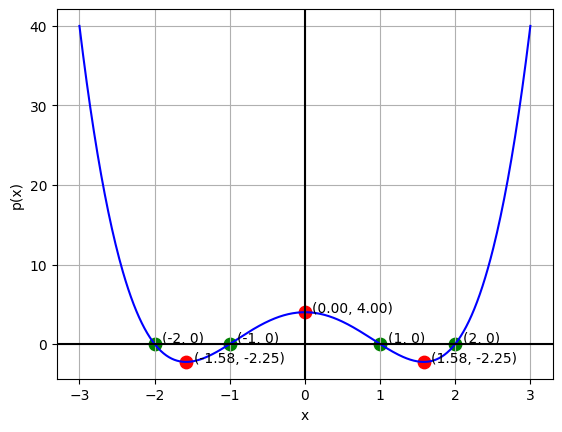

In [5]:

p = np.poly1d([1, 0, -5, 0, 4])

x = np.linspace(-3, 3, 500)
y = p(x)

dp = p.deriv()
d2p = dp.deriv()

x_crit = dp.r
y_crit = p(criticos)

plt.figure()
plt.plot(x, y, color="blue")

plt.scatter(x_crit, y_crit, color="red", s=80)

for xc, yc in zip(x_crit, y_crit):
    plt.text(xc + 0.1, yc, f"({xc:.2f}, {yc:.2f})")

# Para graficar las raíces

# Obtiene las raíces del polinomio
raices = p.r

# usamos raices vs un arreglo de ceros
plt.scatter(raices, np.zeros(len(raices)), color="green", s=80)

# Etiqueta las raíces
for xr in raices:
    plt.text(xr + 0.1, 0.2, f"({xr:.0f}, 0)")

plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid()
plt.show()

### Ejercicio

Considere el polinomio

$$
p(x)=x^3-6x^2+9x+1.
$$

1. Obtenga sus puntos críticos.
2. Clasifique cada punto como máximo o mínimo.
3. Represente gráficamente el polinomio.

